## LIVE CODING 1

El Seeds Dataset es un conjunto de datos clásico utilizado en machine learning para tareas de clasificación y análisis multivariado. El dataset contiene mediciones geométricas de granos de trigo pertenecientes a tres variedades distintas: Kama, Rosa y Canadian. Las mediciones fueron obtenidas a partir de imágenes de los granos utilizando técnicas de procesamiento digital de imágenes. El objetivo habitual al trabajar con este dataset es analizar si, a partir de estas características físicas, es posible distinguir o clasificar correctamente las distintas variedades de trigo.

El dataset contiene 210 observaciones y 7 variables numéricas que describen propiedades geométricas de cada grano. Además incluye una variable que identifica la variedad del trigo.

**Cargar el dataset**

In [ ]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt"

columns = [
    "area",
    "perimeter",
    "compactness",
    "kernel_length",
    "kernel_width",
    "asymmetry_coefficient",
    "kernel_groove_length",
    "class"
]

df = pd.read_csv(url, sep="\\s+", names=columns)

df.head()

,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coefficient,kernel_groove_length,class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


| Columna                     | Descripción                                                                |
| --------------------------- | -------------------------------------------------------------------------- |
| **area**                    | Área del grano de trigo.                                                   |
| **perimeter**               | Perímetro del grano.                                                       |
| **compactness**             | Medida de compactación del grano, calculada como (4π × área / perímetro²). |
| **length_of_kernel**        | Longitud del grano de trigo.                                               |
| **width_of_kernel**         | Ancho del grano.                                                           |
| **asymmetry_coefficient**   | Coeficiente que mide la asimetría del grano.                               |
| **length_of_kernel_groove** | Longitud del surco central del grano.                                      |
| **class**                   | Variedad del trigo (1 = Kama, 2 = Rosa, 3 = Canadian).                     |


**Cargar librerías**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [ ]:
X = df.drop("class", axis=1)
y = df["class"]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Aplicar PCA**

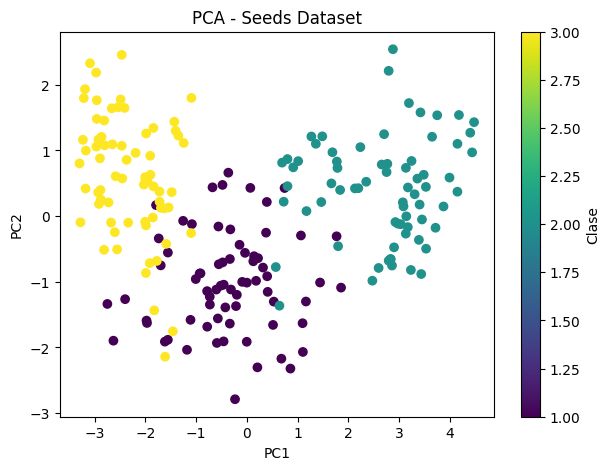

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(7,5))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap="viridis"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - Seeds Dataset")

plt.colorbar(label="Clase")
plt.show()

**Aplicar t-SNE**

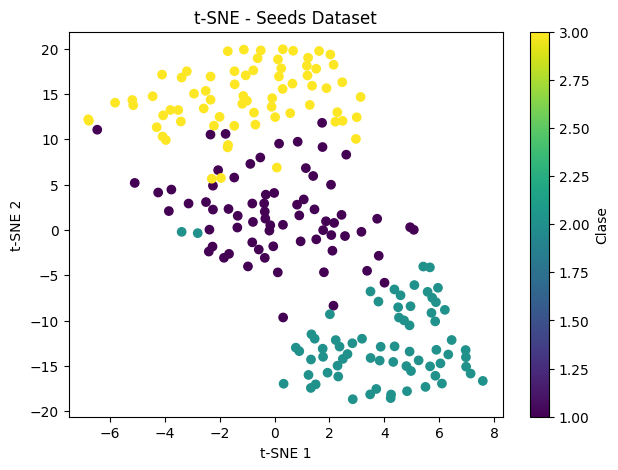

In [ ]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(7,5))

plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=y,
    cmap="viridis"
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE - Seeds Dataset")

plt.colorbar(label="Clase")
plt.show()

**Comparación visual**

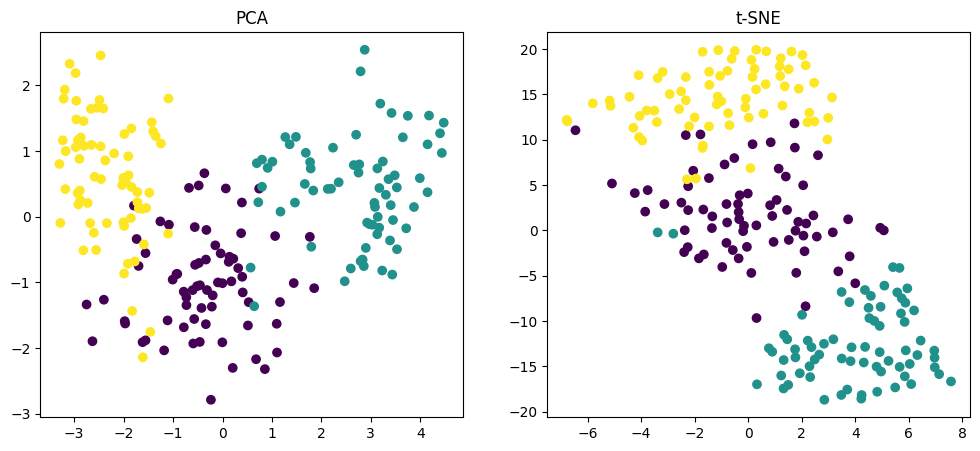

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

axes[0].scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="viridis")
axes[0].set_title("PCA")

axes[1].scatter(X_tsne[:,0], X_tsne[:,1], c=y, cmap="viridis")
axes[1].set_title("t-SNE")

plt.show()

Interpretación del gráfico con PCA

En el gráfico de PCA (izquierda) se observa que:
* aparecen tres agrupaciones generales
* una clase (la de la derecha) está bastante bien separada
* las otras dos clases presentan algo de solapamiento

Esto ocurre porque PCA es un método lineal.
Su objetivo es encontrar las direcciones donde hay mayor varianza en los datos, no necesariamente donde las clases se separan mejor.

PCA logra capturar la estructura general del dataset, pero algunas clases todavía se superponen porque el método no considera explícitamente la separación entre grupos.

Interpretación del gráfico con t-SNE

En el gráfico de t-SNE (derecha):
* los puntos se agrupan en tres clusters más compactos
* la separación entre grupos es mucho más clara
* los puntos de cada clase están más concentrados

Esto pasa porque t-SNE preserva la estructura local del dataset, es decir:
* puntos que eran vecinos en el espacio original permanecen cercanos.

t-SNE intenta mantener juntas las observaciones que eran similares en el espacio original, por lo que los grupos aparecen más compactos y visualmente más separados.

# **PARTE 2**

* Selección del Número de Componentes en PCA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Cargar dataset Seeds desde UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt"

columns = [
    "area",
    "perimeter",
    "compactness",
    "kernel_length",
    "kernel_width",
    "asymmetry_coefficient",
    "kernel_groove_length",
    "class"
]

df = pd.read_csv(url, sep=r"\s+", names=columns)

# 2. Separar variables predictoras
X = df.drop("class", axis=1)

# 3. Estandarizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Aplicar PCA completo
pca = PCA()
pca.fit(X_scaled)

# 5. Varianza explicada
var_exp = pca.explained_variance_ratio_
var_acum = np.cumsum(var_exp)

# 6. Mostrar resultados
resultados = pd.DataFrame({
    "Componente": [f"PC{i}" for i in range(1, len(var_exp) + 1)],
    "Varianza_Explicada": var_exp,
    "Varianza_Acumulada": var_acum
})

print(resultados)

  Componente  Varianza_Explicada  Varianza_Acumulada
0        PC1            0.718743            0.718743
1        PC2            0.171082            0.889825
2        PC3            0.096858            0.986682
3        PC4            0.009766            0.996449
4        PC5            0.002673            0.999122
5        PC6            0.000762            0.999884
6        PC7            0.000116            1.000000


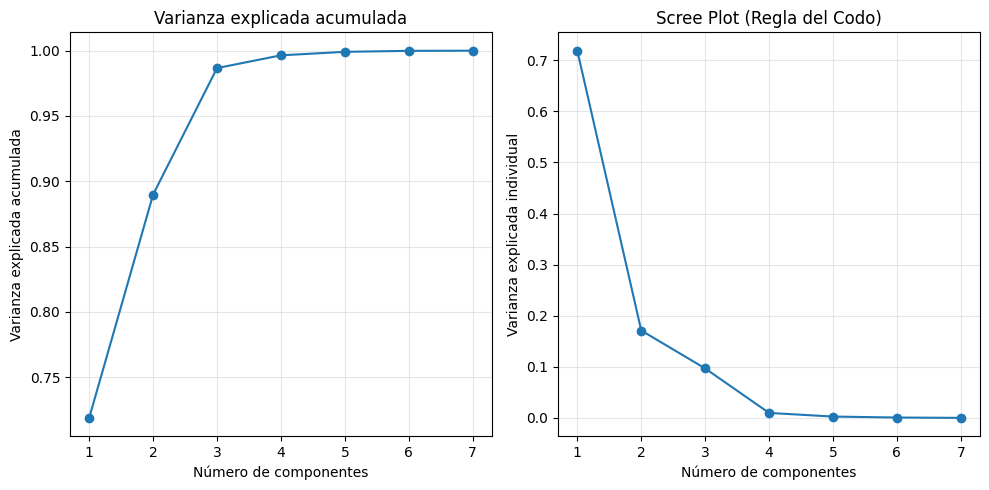

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))

# 1. Varianza acumulada
axes[0].plot(range(1, len(var_acum) + 1), var_acum, marker="o")
axes[0].set_xlabel("Número de componentes")
axes[0].set_ylabel("Varianza explicada acumulada")
axes[0].set_title("Varianza explicada acumulada")
axes[0].set_xticks(range(1, len(var_acum) + 1))
axes[0].grid(True, alpha=0.3)

# 2. Scree plot / codo
axes[1].plot(range(1, len(var_exp) + 1), var_exp, marker="o")
axes[1].set_xlabel("Número de componentes")
axes[1].set_ylabel("Varianza explicada individual")
axes[1].set_title("Scree Plot (Regla del Codo)")
axes[1].set_xticks(range(1, len(var_exp) + 1))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Grafico 1:
1. Componente ya explica 72% de la información
2. Componentes explican 89%
3. Componentes explican casi toda la varianza (~99%)

Con solo dos componentes principales ya capturamos cerca del 90% de la información del dataset.

Gráfico 2:
* PC1 aporta mucho (~72%)
* PC2 aporta bastante (~17%)
* PC3 aporta poco (~9%)
* desde PC4 en adelante casi no aportan información


## Ajuste de Hiperparámetros en t-SNE

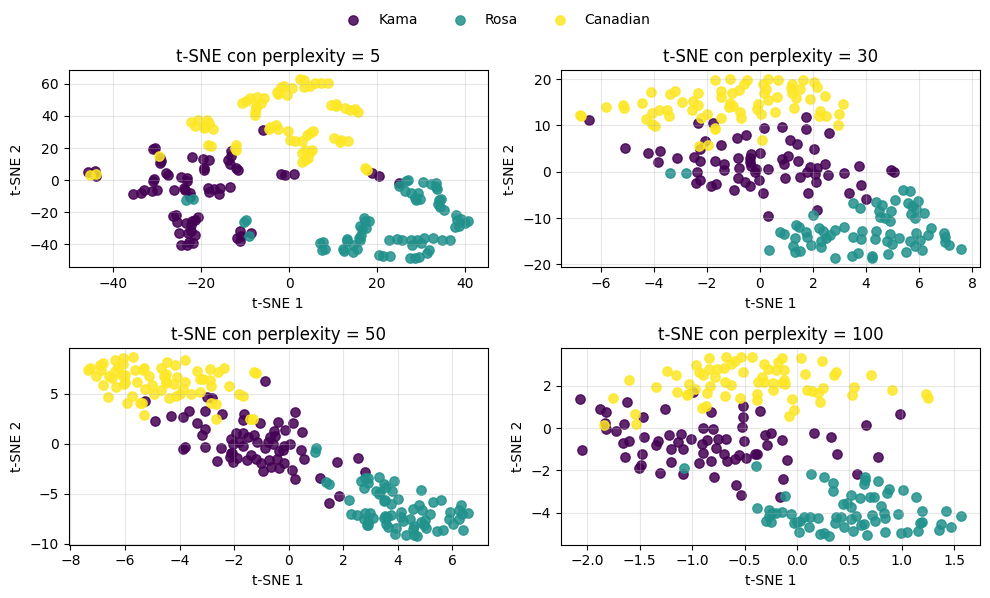

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# 1. Cargar dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt"

columns = [
    "area",
    "perimeter",
    "compactness",
    "kernel_length",
    "kernel_width",
    "asymmetry_coefficient",
    "kernel_groove_length",
    "class"
]

df = pd.read_csv(url, sep=r"\s+", names=columns)

# 2. Mapear nombres
class_names = {
    1: "Kama",
    2: "Rosa",
    3: "Canadian"
}
df["class_name"] = df["class"].map(class_names)

# 3. Separar variables
X = df.drop(["class", "class_name"], axis=1)
y = df["class"]
y_names = df["class_name"]

# 4. Escalar
X_scaled = StandardScaler().fit_transform(X)

# 5. Valores de perplexity
perplexities = [5, 30, 50, 100]

# 6. Colores
colors = {
    "Kama": "#440154",
    "Rosa": "#21918c",
    "Canadian": "#fde725"
}

# 7. Subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.flatten()

for i, perplexity in enumerate(perplexities):
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=42,
        max_iter=1000
    )

    X_tsne = tsne.fit_transform(X_scaled)

    for clase in class_names.values():
        idx = y_names == clase
        axes[i].scatter(
            X_tsne[idx, 0],
            X_tsne[idx, 1],
            label=clase,
            s=45,
            alpha=0.85,
            color=colors[clase]
        )

    axes[i].set_title(f"t-SNE con perplexity = {perplexity}")
    axes[i].set_xlabel("t-SNE 1")
    axes[i].set_ylabel("t-SNE 2")
    axes[i].grid(True, alpha=0.3)

# Leyenda única
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Código para Combinar PCA y t-SNE

* Usando load_digits()

Primero usamos PCA para reducir la dimensionalidad del dataset sin perder demasiada información y eliminar parte del ruido. Luego aplicamos t-SNE sobre esa representación reducida para obtener una visualización en dos dimensiones donde los grupos se observan con mayor claridad.

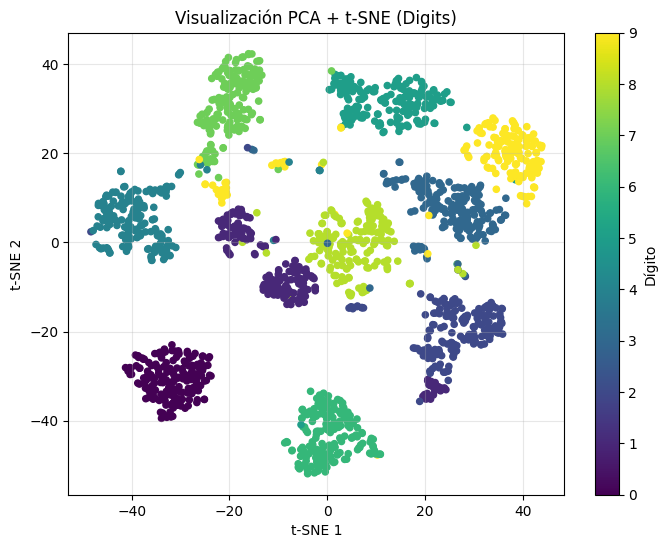

In [18]:
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 1. Cargar dataset
digits = load_digits()
X = digits.data
y = digits.target

# 2. Escalar
X_scaled = StandardScaler().fit_transform(X)

# 3. PCA a 50 dimensiones
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_scaled)

# 4. t-SNE a 2 dimensiones
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_pca)

# 5. Visualizar
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis', s=20)
plt.colorbar(scatter, label="Dígito")
plt.title("Visualización PCA + t-SNE (Digits)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True, alpha=0.3)
plt.show()